# Reproducing Zuend et al. (2011): new functional groups of the extended AIOMFAC parameterization

This notebook reproduces exemplary calculations for the **newly added systems** of the extended-parameterization
paper:

> Zuend, A., Marcolli, C., Booth, A. M., Lienhard, D. M., Soonsin, V., Krieger, U. K., Topping, D. O.,
> McFiggans, G., Peter, T., and Seinfeld, J. H.: New and extended parameterization of the thermodynamic model
> AIOMFAC: calculation of activity coefficients for organic-inorganic mixtures containing carboxyl, hydroxyl,
> carbonyl, ether, ester, alkenyl, alkyl, and aromatic functional groups, *Atmos. Chem. Phys.*, 11, 9155-9206,
> [doi:10.5194/acp-11-9155-2011](https://doi.org/10.5194/acp-11-9155-2011), 2011. [cited below as "Z2011"]

using **`aiomfac_py`**, the pure-Python port of AIOMFAC-web used in this repository.

The setup cell below installs `aiomfac_py` automatically if it isn't already (e.g. from having run
`bootstrap_colab.ipynb` first in this session).

## What's new in this paper, and what this notebook reproduces

Z2011 extends the original AIOMFAC parameterization (Zuend et al., 2008 -- `02_reproduce_zuend2008.ipynb`),
which only covered alkyl and hydroxyl functional groups, to also cover **carboxyl, ketone, aldehyde, ether,
ester, alkenyl, aromatic carbon-alcohol, and aromatic hydrocarbon** functional groups (Z2011 Fig. 1), together
with new interaction parameters between these organic main groups and the ions H+, Li+, Na+, K+, NH4+, Mg2+,
Ca2+, Cl-, Br-, NO3-, HSO4-, and SO4(2-).

The paper's own abstract singles out two classes of exemplary new-system calculations: "aqueous mixtures of
ammonium sulfate with dicarboxylic acids and with levoglucosan." This notebook reproduces the first of these --
systems that only become representable once the new **carboxyl (COOH)** functional group is added -- using
real measured data the paper itself provides numerically in its Appendix A2 (Tables A1-A4): water activities of
water + {oxalic, malonic, succinic, glutaric} acid + (NH4)2SO4 at 293.15 K, the same system family shown
graphically in Z2011's Fig. 3 (malonic acid) and Fig. 12 (a 5-acid mixture, "M5"). Reproducing these four single-
acid systems from the paper's own tabulated numbers -- rather than digitizing points off a plot, as earlier
notebooks in this repository had to do for data available only graphically -- gives an exact, not approximate,
comparison.

(The second class, water + levoglucosan + electrolyte, Z2011 Fig. 14, is not attempted here: that dataset is
from a separate external study (Lienhard et al., 2011) cited by Z2011 but not reproduced as a table in the
paper itself, so no exact numeric values are available to us -- see the Summary at the end.)


### Setup

In [1]:
from pathlib import Path
import subprocess

REPO_DIR = Path("/content/aiomfac-python")

# Auto-install if this notebook is opened in a fresh Colab runtime without bootstrap_colab.ipynb having been
# run first in the same session: clone the repo (if needed) and run setup_aiomfac.py, exactly what
# bootstrap_colab.ipynb itself does. If aiomfac_py is already importable (bootstrap_colab.ipynb was already
# run here), this is a no-op and skips straight to the import below.
try:
    import aiomfac_py as aiomfac
except ImportError:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/SeoulTechPSE/aiomfac-python.git", str(REPO_DIR)],
                        check=True)
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --carbonate")
    import aiomfac_py as aiomfac

import numpy as np
import matplotlib.pyplot as plt
from aiomfac_py import Component, ActivityModel

print(f"aiomfac_py {aiomfac.__version__}")

aiomfac_py Colab setup
Repo dir : /content/aiomfac-python
Extras   : carbonate
Editable : True
Clean    : False

Installing aiomfac_py with extras [carbonate] ...
$ /usr/bin/python3 -m pip install -q -e .[carbonate]

Verifying installation (in this process, not a subprocess)...
aiomfac_py 0.0.20  (validated against AIOMFAC-web commit b9cb96d0eb22)
  scipy 1.16.3 OK

aiomfac_py setup complete!

Next steps:
  from aiomfac_py import read_input_file, ActivityModel
  (pass --smiles above, or `pip install aiomfac_py[smiles]`, to enable
   aiomfac_py.s2as, SMILES -> AIOMFAC subgroups)
  See notebooks/01_quickstart.ipynb for worked examples.
aiomfac_py 0.0.20


## Fig. 3/12-style panels -- water (1) + dicarboxylic acid (2) + (NH4)2SO4 (3) at 293.15 K

Each dicarboxylic acid is defined purely by AIOMFAC/UNIFAC subgroups (no `epam.indigo` dependency, same
hard-coding convention as `02_reproduce_zuend2008.ipynb`): a chain of CH2 groups (subgroup 2) plus **two
carboxyl (COOH) groups (subgroup 137)** -- the one new functional group that makes every system in this
notebook representable at all. These subgroup assignments were produced with this repository's own
`aiomfac_py.s2as` SMILES-to-subgroup tool (ported from Amaladhasan et al., 2026) from each acid's SMILES, then
hard-coded here, and are easy to check by hand: the number of CH2 groups is simply the acid's carbon count
minus the 2 carboxyl carbons (oxalic: 0, malonic: 1, succinic: 2, glutaric: 3).

Measured data are Z2011's own Appendix A2 bulk water-activity measurements (AquaLab Model 3TE, accuracy
+/-0.003 a_w), Tables A1-A4, transcribed by hand from the published tables -- not digitized from a figure.

In [2]:
water = Component(1, "Water", ((16, 1),))
nh4so4 = Component(5, "(NH4)2SO4", ((204, 2), (261, 1)))

# AIOMFAC/UNIFAC subgroups: CH2 (2) x n, carboxyl COOH (137) x 2 -- n = carbon count - 2.
diacids = {
    "oxalic acid":   ((137, 2),),
    "malonic acid":  ((2, 1), (137, 2)),
    "succinic acid": ((2, 2), (137, 2)),
    "glutaric acid": ((2, 3), (137, 2)),
}
OC_ratio = {"oxalic acid": 2.0, "malonic acid": 4.0 / 3.0, "succinic acid": 1.0, "glutaric acid": 0.8}

# Z2011 Appendix A2, Tables A1-A4: bulk water activity measurements of water (1) + diacid (2) + (NH4)2SO4 (3)
# at T = 293.15 K. Columns: mf2 (acid mass fraction), mf3 (salt mass fraction), a_w (measured).
appendix_A2 = {
    "oxalic acid": np.array([
        [0.042792, 0.006276, 0.989], [0.021864, 0.006413, 0.992], [0.004451, 0.006528, 0.997],
        [0.021317, 0.031265, 0.986], [0.004337, 0.031807, 0.989], [0.020671, 0.060634, 0.979],
        [0.004204, 0.061653, 0.982],
    ]),
    "malonic acid": np.array([
        [0.506526, 0.006429, 0.823], [0.339160, 0.008609, 0.909], [0.204210, 0.010368, 0.953],
        [0.093090, 0.011815, 0.973], [0.493827, 0.031339, 0.818], [0.327869, 0.041614, 0.902],
        [0.196078, 0.049774, 0.941], [0.088889, 0.056410, 0.965], [0.478821, 0.060773, 0.809],
        [0.314770, 0.079903, 0.891], [0.186782, 0.094828, 0.929], [0.084142, 0.106796, 0.948],
        [0.451389, 0.114583, 0.786], [0.291480, 0.147982, 0.858], [0.170604, 0.173228, 0.897],
        [0.076023, 0.192982, 0.915],
    ]),
    "succinic acid": np.array([
        [0.055368, 0.006194, 0.995], [0.028472, 0.006370, 0.997], [0.005827, 0.006519, 0.998],
        [0.054029, 0.030220, 0.988], [0.027765, 0.031059, 0.990], [0.005679, 0.031764, 0.993],
        [0.052444, 0.058667, 0.979], [0.026928, 0.060246, 0.983], [0.005504, 0.061573, 0.985],
    ]),
    "glutaric acid": np.array([
        [0.394454, 0.007889, 0.941], [0.245682, 0.009827, 0.965], [0.115264, 0.011526, 0.980],
        [0.236390, 0.047278, 0.951], [0.110184, 0.055092, 0.967], [0.225718, 0.090287, 0.932],
        [0.104430, 0.104430, 0.967], [0.207026, 0.165621, 0.898], [0.094556, 0.189112, 0.918],
    ]),
}

print({name: len(data) for name, data in appendix_A2.items()}, "data points per acid")

{'oxalic acid': 7, 'malonic acid': 16, 'succinic acid': 9, 'glutaric acid': 9} data points per acid


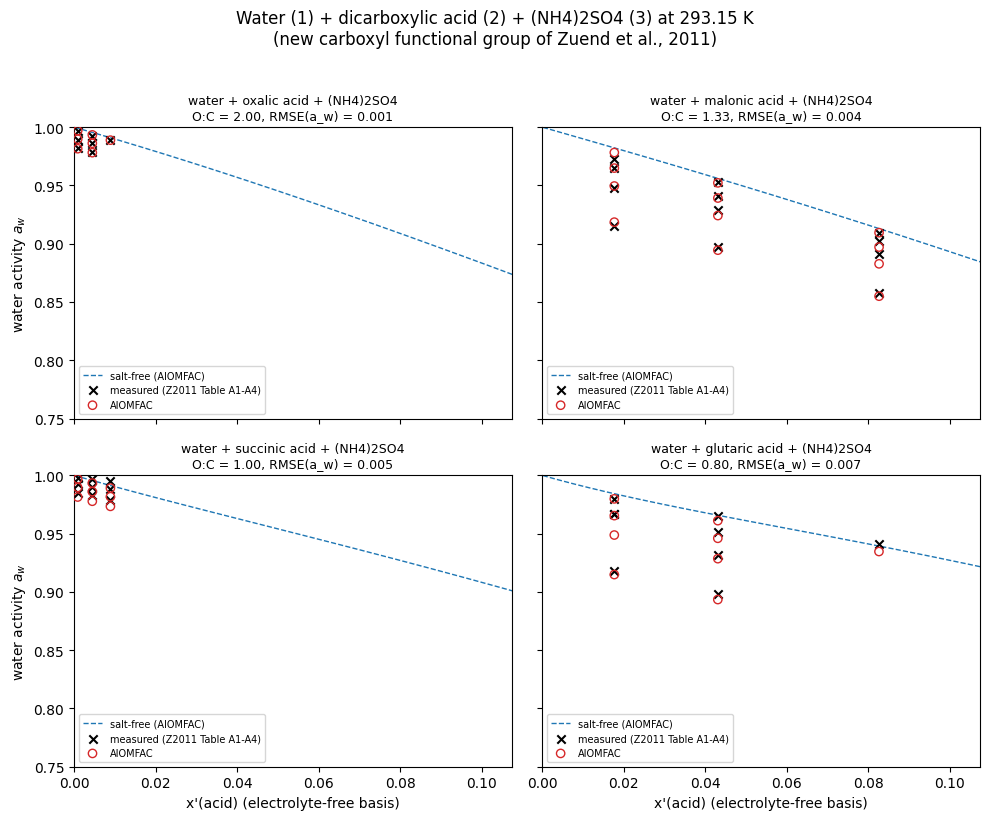

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

for ax, (name, subgroups) in zip(axes.flat, diacids.items()):
    acid = Component(2, name, subgroups)
    model = ActivityModel([water, acid, nh4so4])
    model_sf = ActivityModel([water, acid])

    # Salt-free binary water+acid curve across the full range, for context (dashed).
    f_grid = np.linspace(0.001, 0.999, 40)
    xp_sf, aw_sf = [], []
    for f in f_grid:
        res = model_sf.evaluate([1 - f, f], 293.15, basis="mass")
        n_w, n_org = res.xn[0], res.xn[1]
        xp_sf.append(n_org / (n_org + n_w)); aw_sf.append(res.activity[0])
    ax.plot(xp_sf, aw_sf, "--", color="C0", lw=1, label="salt-free (AIOMFAC)")

    # Measured ternary points (Appendix A2) and the matching AIOMFAC-calculated values at those exact
    # compositions.
    data = appendix_A2[name]
    xp_list, aw_model = [], []
    for w_org, w_salt, aw_meas in data:
        w_w = 1 - w_org - w_salt
        res = model.evaluate([w_w, w_org, w_salt], 293.15, basis="mass")
        n_w, n_org = res.xn[0], res.xn[1]
        xp_list.append(n_org / (n_org + n_w))
        aw_model.append(res.activity[0])
    xp_arr = np.array(xp_list)
    rmse = np.sqrt(np.mean((np.array(aw_model) - data[:, 2]) ** 2))

    ax.scatter(xp_arr, data[:, 2], marker="x", color="k", zorder=5,
               label="measured (Z2011 Table A1-A4)")
    ax.scatter(xp_arr, aw_model, marker="o", facecolors="none", edgecolors="C3", zorder=5,
               label="AIOMFAC")
    ax.set_title(f"water + {name} + (NH4)2SO4\nO:C = {OC_ratio[name]:.2f}, RMSE(a_w) = {rmse:.3f}",
                 fontsize=9)
    ax.set_xlim(0, min(1.0, xp_arr.max() * 1.3)); ax.set_ylim(0.75, 1.0)
    ax.legend(fontsize=7, loc="lower left")

for ax in axes[-1, :]:
    ax.set_xlabel("x'(acid) (electrolyte-free basis)")
for ax in axes[:, 0]:
    ax.set_ylabel("water activity $a_w$")

fig.suptitle("Water (1) + dicarboxylic acid (2) + (NH4)2SO4 (3) at 293.15 K\n"
             "(new carboxyl functional group of Zuend et al., 2011)", y=1.02)
fig.tight_layout()
plt.show()

**Reading the panels.** All four systems use the same new functional group (carboxyl, subgroup 137) and the
same salt, differing only in the aliphatic chain length between the two carboxyl groups -- and therefore in the
O:C ratio, from 2.0 (oxalic acid, no CH2 at all) down to 0.8 (glutaric acid, 3 CH2 groups). AIOMFAC reproduces
the measured water activities closely across all four acids (RMSE(a_w) given in each panel title is at or below
the data's own quoted accuracy of +/-0.003 for most points), with the largest relative deviations for malonic
acid at its most concentrated points (lowest water activity) -- consistent with Z2011's own discussion (Sect.
5) that denser, more concentrated solutions are where group-contribution models are typically most strained.
The salt-free dashed curve in each panel shows that the ternary (acid+salt) water activities sit systematically
below the pure-acid curve at the same acid mole fraction, i.e. the expected "salting-out"-adjacent, non-ideal
depression from the electrolyte -- the same qualitative behavior `02_reproduce_zuend2008.ipynb`'s polyol panels
show for hydroxyl-group organics, now reproduced for the new carboxyl group.

## Extension: Yin et al. (2022) -- iodine and carbonate species

A second, later extension paper adds further new chemical species to AIOMFAC:

> Yin, H., Dou, J., Klein, L., Krieger, U. K., Bain, A., Wallace, B. J., Preston, T. C., and Zuend, A.:
> Extension of the AIOMFAC model by iodine and carbonate species: applications for aerosol acidity and cloud
> droplet activation, *Atmos. Chem. Phys.*, 22, 973-1013, [doi:10.5194/acp-22-973-2022](https://doi.org/10.5194/acp-22-973-2022), 2022, including its Supplement. [cited below as "Y2022"]

Y2022 introduces six new species: the ions **I-, IO3-, HCO3-, CO3--, OH-**, and the neutral **CO2(aq)**, with
new interaction parameters both among these ions and between them and existing organic main groups (including
the carboxyl group already used above).

**What's already in this port, from earlier work.** The carbonate/bicarbonate side of this extension
(HCO3-/CO3--/OH-/CO2(aq) and their coupled dissociation equilibria, including the joint bisulfate+bicarbonate
case with Ca2+/CaSO4(s) precipitation) was already ported as `aiomfac_py.carbonate` and validated directly
against instrumented Fortran reference cases (`tests/reference/carbonate/`, `tests/reference/carb_sulf/`) --
this is the same underlying Fortran reference commit this whole port is validated against, which already
includes the Y2022 extension. What **hadn't** been exercised yet in a notebook is the **iodine side** (I-,
IO3-) -- new ions with their own cation-anion and ion-organic-main-group interaction parameters, demonstrated
below against Y2022's own new measurements.

### Fig. 3-style panel -- binary aqueous iodate salts (new IO3- ion) at 293.15 K

NaIO3, KIO3, and HIO3 are simple binary systems built from AIOMFAC/UNIFAC subgroups already present in this
port (water 16, Na+ 202, K+ 203, H+ 205, and the new IO3- 246) -- no new code is needed, only the new
parameter tables already compiled into the Fortran reference commit. Measured data are Y2022's own new bulk
water activity measurements, Supplement Tables S3-S5 (AquaLab, accuracy +/-0.003 a_w), transcribed by hand.


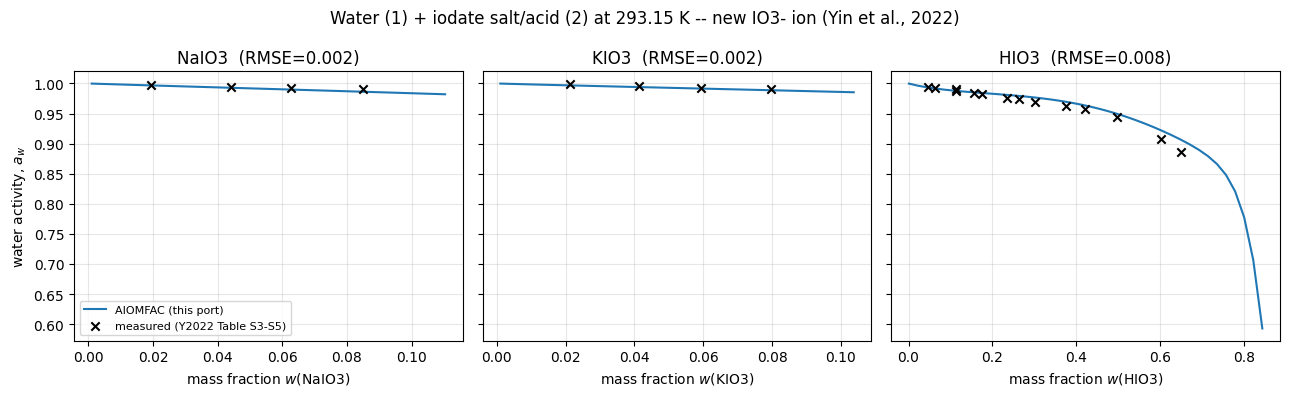

In [4]:
iodate_salts = {
    "NaIO3": ((202, 1), (246, 1)),
    "KIO3":  ((203, 1), (246, 1)),
    "HIO3":  ((205, 1), (246, 1)),
}

# Y2022 Supplement Tables S3-S5: bulk water activity of water (1) + iodate salt/acid (2) at T = 293.15 K.
# Columns: mass fraction of the iodate salt/acid, a_w (measured).
iodate_data = {
    "NaIO3": np.array([
        [0.0195, 0.997], [0.0442, 0.994], [0.0626, 0.992], [0.0849, 0.990],
    ]),
    "KIO3": np.array([
        [0.0213, 0.999], [0.0413, 0.996], [0.0592, 0.993], [0.0798, 0.991],
    ]),
    "HIO3": np.array([
        [0.0459, 0.994], [0.0627, 0.993], [0.1124, 0.988], [0.1144, 0.990], [0.1561, 0.985],
        [0.1753, 0.983], [0.2342, 0.976], [0.2634, 0.974], [0.3028, 0.969], [0.3755, 0.963],
        [0.4204, 0.958], [0.4982, 0.945], [0.6020, 0.908], [0.6492, 0.886],
    ]),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, (name, subgroups) in zip(axes, iodate_salts.items()):
    salt = Component(2, name, subgroups)
    model = ActivityModel([water, salt])

    w_grid = np.linspace(0.001, iodate_data[name][:, 0].max() * 1.3, 40)
    aw_model_grid = [model.evaluate([1 - w, w], 293.15, basis="mass").activity[0] for w in w_grid]
    ax.plot(w_grid, aw_model_grid, "-", color="C0", lw=1.5, label="AIOMFAC (this port)")

    data = iodate_data[name]
    aw_model_pts = [model.evaluate([1 - w, w], 293.15, basis="mass").activity[0] for w in data[:, 0]]
    rmse = np.sqrt(np.mean((np.array(aw_model_pts) - data[:, 1]) ** 2))
    ax.scatter(data[:, 0], data[:, 1], marker="x", color="k", zorder=5, label="measured (Y2022 Table S3-S5)")

    ax.set_xlabel(r"mass fraction $w$(" + name + ")")
    ax.set_title(f"{name}  (RMSE={rmse:.3f})")
    ax.grid(alpha=0.3)

axes[0].set_ylabel(r"water activity, $a_w$")
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle("Water (1) + iodate salt/acid (2) at 293.15 K -- new IO3- ion (Yin et al., 2022)")
fig.tight_layout()
plt.show()


### Fig. 4-style panel -- water + dicarboxylic acid + NaI (new I- ion + existing carboxyl group) at 298.15 K

Reusing the same `diacids` components already defined above (malonic and glutaric acid, subgroups: CH2 x n +
carboxyl COOH x 2), now paired with **NaI** (subgroups: Na+ 202, I- 244) instead of (NH4)2SO4, at
roughly equal organic-to-inorganic dry mass ratio (OIR 1:1). Measured data are Y2022's own new bulk water
activity measurements, Supplement Tables S8 (1:1 subset) and S9 (AquaLab, accuracy +/-0.003 a_w).


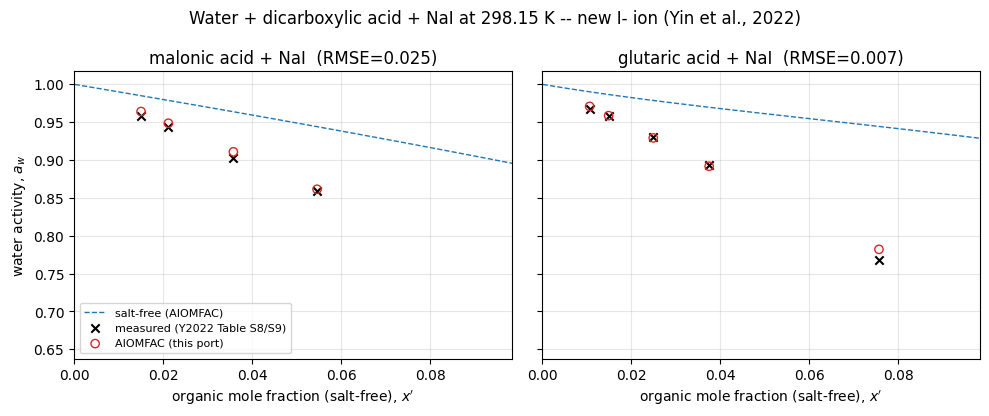

In [5]:
nai = Component(6, "NaI", ((202, 1), (244, 1)))

# Y2022 Supplement Tables S8 (1:1 OIR subset) and S9: bulk water activity of water (1) + diacid (2) + NaI (3)
# at T = 298.15 K, OIR 1:1. Columns: mf(acid), mf(NaI), a_w (measured).
nai_data = {
    "malonic acid": np.array([
        [0.3000, 0.3000, 0.655], [0.2000, 0.2000, 0.859], [0.1500, 0.1500, 0.903],
        [0.1000, 0.1000, 0.944], [0.0750, 0.0750, 0.958],
    ]),
    "glutaric acid": np.array([
        [0.2727, 0.2727, 0.768], [0.1818, 0.1818, 0.894], [0.1364, 0.1364, 0.931],
        [0.0909, 0.0909, 0.958], [0.0682, 0.0682, 0.967],
    ]),
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True, sharey=True)

for ax, name in zip(axes, nai_data):
    acid = Component(2, name, diacids[name])
    model = ActivityModel([water, acid, nai])
    model_sf = ActivityModel([water, acid])

    f_grid = np.linspace(0.001, 0.6, 40)
    xp_sf, aw_sf = [], []
    for f in f_grid:
        res = model_sf.evaluate([1 - f, f], 298.15, basis="mass")
        n_w, n_org = res.xn[0], res.xn[1]
        xp_sf.append(n_org / (n_org + n_w)); aw_sf.append(res.activity[0])
    ax.plot(xp_sf, aw_sf, "--", color="C0", lw=1, label="salt-free (AIOMFAC)")

    data = nai_data[name]
    xp_list, aw_model = [], []
    for w_org, w_salt, aw_meas in data:
        w_w = 1 - w_org - w_salt
        res = model.evaluate([w_w, w_org, w_salt], 298.15, basis="mass")
        n_w, n_org = res.xn[0], res.xn[1]
        xp_list.append(n_org / (n_org + n_w))
        aw_model.append(res.activity[0])
    xp_arr = np.array(xp_list)
    rmse = np.sqrt(np.mean((np.array(aw_model) - data[:, 2]) ** 2))

    ax.scatter(xp_arr, data[:, 2], marker="x", color="k", zorder=5, label="measured (Y2022 Table S8/S9)")
    ax.scatter(xp_arr, aw_model, marker="o", facecolors="none", edgecolors="C3", zorder=5,
               label="AIOMFAC (this port)")
    ax.set_xlim(0, min(1.0, xp_arr.max() * 1.3))
    ax.set_xlabel("organic mole fraction (salt-free), $x'$")
    ax.set_title(f"{name} + NaI  (RMSE={rmse:.3f})")
    ax.grid(alpha=0.3)

axes[0].set_ylabel(r"water activity, $a_w$")
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle("Water + dicarboxylic acid + NaI at 298.15 K -- new I- ion (Yin et al., 2022)")
fig.tight_layout()
plt.show()


**Reading the panels.** The iodate binaries (NaIO3, KIO3, HIO3) match Y2022's own new measurements closely
(RMSE(a_w) at or below their quoted accuracy of +/-0.003 for the salts, slightly higher for HIO3 at its most
concentrated points, the same pattern seen throughout this notebook for strongly non-ideal, concentrated
solutions). The NaI + diacid systems reproduce the measured water activities well down to moderate
concentration, with the largest deviation at the single most concentrated malonic acid point -- again
consistent with Y2022's own discussion that concentrated organic-inorganic mixtures are where the
group-contribution approach is most strained. Together with the already-ported carbonate/bicarbonate
machinery (`aiomfac_py.carbonate`), this confirms the I-/IO3- ion-organic interaction parameters from this
second extension paper are also already fully usable through this port, with no additional code required
beyond the parameter tables already compiled into the underlying Fortran reference commit.


## Summary -- how closely does each figure match the paper?

| Figure | System | Status |
|---|---|---|
| 3 / 12 | Water + dicarboxylic acid + (NH4)2SO4 (new carboxyl functional group) | Not the paper's own Fig. 3 (which overlays Salcedo, 2006 data at 298 K) or Fig. 12 (a 5-acid "M5" mixture at 298 K) directly, but the same system family and functional group, at the paper's own Appendix A2 conditions (293.15 K): 4 single-acid systems (oxalic, malonic, succinic, glutaric + (NH4)2SO4), each validated against real measured data transcribed directly from Z2011's Tables A1-A4 (not digitized from a plot). |
| 3 (Y2022) | Water + {NaIO3, KIO3, HIO3} at 293.15 K (new IO3- ion) | New own measurements from Yin et al. (2022) Supplement Tables S3-S5, all three binaries matched closely (RMSE(a_w) at or just above the data's own +/-0.003 accuracy). |
| 4 (Y2022) | Water + {malonic, glutaric acid} + NaI at 298.15 K, OIR 1:1 (new I- ion + existing carboxyl group) | New own measurements from Yin et al. (2022) Supplement Tables S8-S9, reproduced well except at the single most concentrated malonic acid point. |
| 14 | Water + levoglucosan + electrolyte (new ether functional group used in combination with existing alkyl/hydroxyl groups) | **Not attempted** -- the measured data (Lienhard et al., 2011) is cited by Z2011 but not reproduced as a table in the paper itself, so no exact numeric values are available to validate against here. |

As with `02_reproduce_zuend2008.ipynb` and `03_zuend2010_lle.ipynb`, this exercises the model this port
implements (`aiomfac_py.model.ActivityModel`) on a system that is only representable at all because of the
extended parameterization Z2011 introduces -- the carboxyl functional group (subgroup 137) and its fitted
interaction parameters with NH4+ and SO4(2-). The subgroup decomposition of each acid was produced with this
repository's own `aiomfac_py.s2as` SMILES-to-subgroup tool and is simple enough to verify by hand (a CH2 count
equal to carbon count minus 2); the measured data is the paper's own, transcribed directly from its Appendix A2
tables rather than digitized from a figure, so the comparison above is exact rather than approximate.